# PPLM Generation, Evaluation, and Base-LLM Comparison

This notebook performs the final generation and evaluation experiments for the PPLM baseline and compares its performance with the unsteered `meta-llama/Llama-3.1-8B-Instruct` base model.

The selected PPLM configuration is obtained from the preceding hyperparameter grid search and uses:

- **step size:** `0.5`
- **gradient steps:** `20`
- **temperature:** `0.6`

Both the Base LLM and the selected PPLM configuration are evaluated over three independent stochastic generation runs using the **In-Domain Evaluation Prompt Matrix**.

Generated texts are evaluated with the primary CEFR evaluator:

`MohammadKhosravi/roberta-large-cefr-classifier-JointLoss`

The notebook additionally reports linguistic and structural diagnostics, including Mean Dependency Distance, Flesch Reading Ease, sentence-level CEFR drift, classification reports, and confusion matrices.

Additional temperature-sensitivity runs are also included for diagnostic analysis.

## 1. Base LLM — First Evaluation Run

This section performs the first stochastic generation run for the unsteered
Llama-3.1-8B-Instruct baseline using the in-domain CEFR evaluation matrix.

In [ ]:
!pip install -q transformers torch datasets tqdm huggingface_hub accelerate scikit-learn textstat spacy
!python -m spacy download en_core_web_sm

import os
import gc
import torch
import spacy
import textstat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSequenceClassification
from huggingface_hub import login
from google.colab import drive


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 106.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 31.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# ==========================================
# 0. CONFIGURATION & GOOGLE DRIVE SETUP
# ==========================================
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
INPUT_CSV_PATH = "/content/drive/MyDrive/Your_Path/in_domain_evaluation_prompt_matrix.csv"
OUTPUT_DIR = "/content/drive/MyDrive/Your_Path/pplm_experiments/base_llm"
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_CSV_PATH = os.path.join(OUTPUT_DIR, "benchmark_results_basellm.csv")
OUTPUT_TXT_PATH = os.path.join(OUTPUT_DIR, "overall_metrics_report.txt")
OUTPUT_IMG_PATH = os.path.join(OUTPUT_DIR, "confusion_matrix.png")

hf_token = "HF_Token"
login(token=hf_token)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load NLP tools
nlp = spacy.load("en_core_web_sm")

Using device: cuda


In [ ]:
# ==========================================
# 1. LOAD GENERATIVE LLM & TOKENIZER
# ==========================================
print("Loading Base Llama-3.1-8B-Instruct...")
model_id = "meta-llama/Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)

tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

eot_id = tokenizer.convert_tokens_to_ids("<|eot_id|>\n") if tokenizer.convert_tokens_to_ids("<|eot_id|>\n") is not None else tokenizer.convert_tokens_to_ids("<|eot_id|>. ")
if eot_id is None:
    eot_id = tokenizer.convert_tokens_to_ids("<|eot_id|>")
eos_ids = [tokenizer.eos_token_id]
if eot_id is not None:
    eos_ids.append(eot_id)

model = AutoModelForCausalLM.from_pretrained(
    model_id, torch_dtype=torch.bfloat16, device_map="auto"
)
model.eval()

Loading Base Llama-3.1-8B-Instruct...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((4096,), eps=1e-05)
  

In [ ]:
# ==========================================
# 2. LOAD CUSTOM JOINT LOSS EVALUATOR
# ==========================================
print("Loading Custom JointLoss RoBERTa Evaluator...")
JUDGE_MODEL_ID = "MohammadKhosravi/roberta-large-cefr-classifier-JointLoss"
judge_tokenizer = AutoTokenizer.from_pretrained(JUDGE_MODEL_ID)
judge_model = AutoModelForSequenceClassification.from_pretrained(JUDGE_MODEL_ID).to(device)
judge_model.eval()

label_map = {"A1": 0, "A2": 1, "B1": 2, "B2": 3, "C1": 4, "C2": 5}
inv_label_map = {0: "A1", 1: "A2", 2: "B1", 3: "B2", 4: "C1", 5: "C2"}

Loading Custom JointLoss RoBERTa Evaluator...


config.json:   0%|          | 0.00/900 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/388 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.56M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

In [ ]:
# ==========================================
# 3. METRIC HELPER FUNCTIONS
# ==========================================
def calculate_mdd(text):
    """Calculates Mean Dependency Distance (MDD) using SpaCy"""
    doc = nlp(text)
    total_dist, tokens = 0, 0
    for token in doc:
        if token.dep_ != "punct":
            total_dist += abs(token.i - token.head.i)
            tokens += 1
    return total_dist / tokens if tokens > 0 else 0.0

def calculate_sentence_drift(text, judge_model, judge_tokenizer):
    """Evaluates individual sentences to find the maximum CEFR level drift"""
    doc = nlp(text)
    sentences = [sent.text.strip() for sent in doc.sents if len(sent.text.strip()) > 10]
    if len(sentences) <= 1: return 0  # No drift possible with 1 sentence

    inputs = judge_tokenizer(sentences, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
    with torch.no_grad():
        preds = torch.argmax(judge_model(**inputs).logits, dim=-1).cpu().numpy()

    return int(np.max(preds) - np.min(preds)) # E.g., Max=4(C1), Min=2(B1) -> Drift=2

In [ ]:
# ==========================================
# 4. HYPERPARAMETERS
# ==========================================
BATCH_SIZE = 128  # Scaled for A100
temperature = 0.6
repetition_penalty = 1.15
max_new_tokens = 200
top_k = 50

In [ ]:
# ==========================================
# 5. BATCH PROCESSING ENGINE
# ==========================================
df = pd.read_csv(INPUT_CSV_PATH)

if os.path.exists(OUTPUT_CSV_PATH):
    print(f"Resuming execution from: {OUTPUT_CSV_PATH}")
    results_df = pd.read_csv(OUTPUT_CSV_PATH)
    processed_ids = results_df['topic_id'].tolist()
    results = results_df.to_dict('records')
else:
    processed_ids = []
    results = []

print(f"\n🚀 LAUNCHING BATCHED BASE LLM ENGINE (Batch Size: {BATCH_SIZE})...")

for b_start in range(0, len(df), BATCH_SIZE):
    batch_df = df.iloc[b_start : b_start + BATCH_SIZE]
    batch_df = batch_df[~batch_df['topic_id'].isin(processed_ids)]
    if batch_df.empty: continue

    current_batch_size = len(batch_df)
    print(f"Processing batch rows {b_start} to {b_start + current_batch_size}...")

    batch_prompts, batch_targets, batch_topic_ids, batch_titles = [], [], [], []

    for _, row in batch_df.iterrows():
        t_cefr = str(row['cefr']).strip().upper()
        batch_targets.append(t_cefr)
        batch_topic_ids.append(row['topic_id'])
        batch_titles.append(row['topic_title'])

        sys_instr = (
            f"You are an expert English language teacher demonstrating CEFR proficiency levels. "
            f"Your task is to write a flawless, grammatically correct text responding to this prompt: '{row['topic_title']}'. "
            f"The output must serve as a perfect textbook example of strictly {t_cefr} level English. "
            f"If the requested target level is A1/A2, use very simple vocabulary, short sentences, and primitive structures. "
            f"If the requested target level is C1/C2, utilize highly advanced vocabulary, idioms, and complex sentence patterns. "
            f"Write only the direct response. Do not write any meta-commentary, greetings, or conversational pleasantries."
        )
        messages = [{"role": "system", "content": sys_instr}, {"role": "user", "content": row['topic_title']}]
        batch_prompts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))

    inputs = tokenizer(batch_prompts, padding=True, return_tensors="pt").to(device)

    # 1. GENERATE
    with torch.no_grad():
        base_outputs = model.generate(
            inputs.input_ids, attention_mask=inputs.attention_mask,
            max_new_tokens=max_new_tokens, temperature=temperature,
            do_sample=True, top_k=top_k, repetition_penalty=repetition_penalty,
            pad_token_id=tokenizer.pad_token_id, eos_token_id=eos_ids
        )

    batch_gen_texts = []
    for b_idx in range(current_batch_size):
        gen_tokens = base_outputs[b_idx][inputs.input_ids.shape[1]:]
        batch_gen_texts.append(tokenizer.decode(gen_tokens, skip_special_tokens=True).strip())

    # 2. EVALUATE (Whole Text)
    eval_inputs = judge_tokenizer(batch_gen_texts, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
    with torch.no_grad():
        eval_preds = torch.argmax(judge_model(**eval_inputs).logits, dim=-1).cpu().numpy()

    # 3. APPEND ROW-BY-ROW METRICS
    for b_idx in range(current_batch_size):
        target_cefr = batch_targets[b_idx]
        predicted_cefr = inv_label_map.get(eval_preds[b_idx], "A1")
        gen_text = batch_gen_texts[b_idx]

        is_strict = int(predicted_cefr == target_cefr)
        is_adjacent = int(abs(label_map[predicted_cefr] - label_map[target_cefr]) <= 1)

        try: flesch_score = textstat.flesch_reading_ease(gen_text)
        except: flesch_score = 0.0

        mdd_score = calculate_mdd(gen_text)
        drift_score = calculate_sentence_drift(gen_text, judge_model, judge_tokenizer)

        results.append({
            "topic_id": batch_topic_ids[b_idx],
            "topic_title": batch_titles[b_idx],
            "target_cefr": target_cefr,
            "predicted_cefr": predicted_cefr,
            "strict_match": is_strict,
            "adjacent_match": is_adjacent,
            "mdd": round(mdd_score, 2),
            "readability_flesch": round(flesch_score, 2),
            "sentence_drift_max": drift_score,
            "generated_text": gen_text
        })

    pd.DataFrame(results).to_csv(OUTPUT_CSV_PATH, index=False)
    processed_ids = [r['topic_id'] for r in results]

    del inputs, base_outputs, eval_inputs
    torch.cuda.empty_cache()
    gc.collect()

print(f"\n✅ GENERATION & ROW METRICS COMPLETE. Saved to: {OUTPUT_CSV_PATH}")


🚀 LAUNCHING BATCHED BASE LLM ENGINE (Batch Size: 128)...
Processing batch rows 0 to 128...


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Processing batch rows 128 to 252...
Processing batch rows 256 to 382...
Processing batch rows 384 to 512...
Processing batch rows 512 to 636...
Processing batch rows 640 to 700...

✅ GENERATION & ROW METRICS COMPLETE. Saved to: /content/drive/MyDrive/Mohammd_Thesis/Results/BaseLLM/benchmark_results_basellm.csv


📄 Macro metrics report saved to: /content/drive/MyDrive/Mohammd_Thesis/Results/BaseLLM/overall_metrics_report.txt
 📊 FINAL COMPILED MACRO-STATISTICS (BASE LLM)
Total Processed       : 690
Strict Accuracy       : 24.64%
Adjacent Accuracy     : 63.19%
Mean Abs Error (MAE)  : 1.3275
Avg MDD Score         : 2.00
Avg Reading Ease      : 49.47
Avg Sentence Drift    : 3.04 levels

📈 PERFORMANCE BREAKDOWN BY CEFR TARGET LEVEL:
             strict_accuracy  avg_mdd  avg_flesch  avg_drift
target_cefr                                                 
A1                     16.24     1.73       82.56       3.25
A2                     23.08     1.64       85.44       3.27
B1                     17.39     2.03       57.80       3.11
B2                     41.74     2.15       34.18       2.97
C1                     33.63     2.24       18.95       2.94
C2                     15.93     2.25       15.54       2.69

📝 DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support


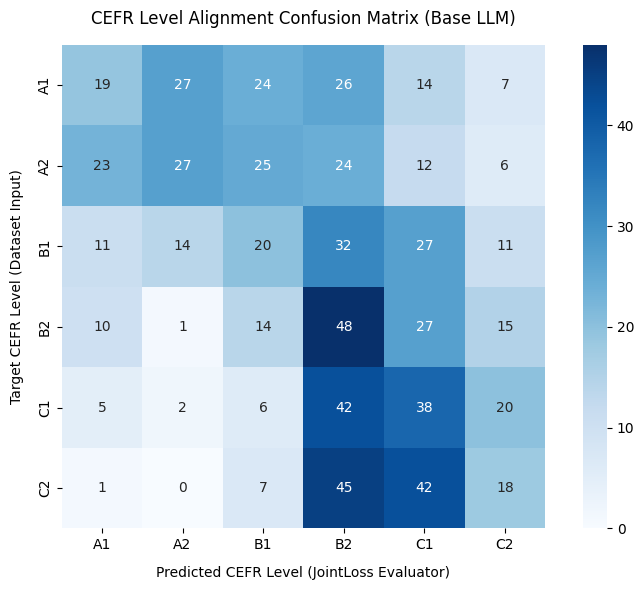

In [ ]:
# ==========================================
# 6. MACRO METRICS COMPILATION & EXPORT
# ==========================================
df_final = pd.read_csv(OUTPUT_CSV_PATH)
y_true_labels = df_final['target_cefr'].astype(str).str.strip().str.upper()
y_pred_labels = df_final['predicted_cefr'].astype(str).str.strip().str.upper()

# Map to numerical for MAE
y_true_num = y_true_labels.map(label_map)
y_pred_num = y_pred_labels.map(label_map)

# Calculate Macro Stats
total_samples = len(df_final)
strict_acc = df_final['strict_match'].mean() * 100
adj_acc = df_final['adjacent_match'].mean() * 100
mae = mean_absolute_error(y_true_num, y_pred_num)
avg_mdd = df_final['mdd'].mean()
avg_flesch = df_final['readability_flesch'].mean()
avg_drift = df_final['sentence_drift_max'].mean()

# Generate Report Text
report_text = "="*60 + "\n"
report_text += " 📊 FINAL COMPILED MACRO-STATISTICS (BASE LLM)\n"
report_text += "="*60 + "\n"
report_text += f"Total Processed       : {total_samples}\n"
report_text += f"Strict Accuracy       : {strict_acc:.2f}%\n"
report_text += f"Adjacent Accuracy     : {adj_acc:.2f}%\n"
report_text += f"Mean Abs Error (MAE)  : {mae:.4f}\n"
report_text += f"Avg MDD Score         : {avg_mdd:.2f}\n"
report_text += f"Avg Reading Ease      : {avg_flesch:.2f}\n"
report_text += f"Avg Sentence Drift    : {avg_drift:.2f} levels\n"
report_text += "="*60 + "\n\n"

report_text += "📈 PERFORMANCE BREAKDOWN BY CEFR TARGET LEVEL:\n"
level_agg = df_final.groupby("target_cefr").agg(
    strict_accuracy=("strict_match", lambda x: np.mean(x) * 100),
    avg_mdd=("mdd", "mean"),
    avg_flesch=("readability_flesch", "mean"),
    avg_drift=("sentence_drift_max", "mean")
).round(2)
report_text += level_agg.to_string() + "\n\n"

report_text += "="*60 + "\n"
report_text += "📝 DETAILED CLASSIFICATION REPORT:\n"
cefr_labels = ["A1", "A2", "B1", "B2", "C1", "C2"]
report_text += classification_report(y_true_labels, y_pred_labels, labels=cefr_labels, zero_division=0)
report_text += "\n" + "="*60 + "\n"

# Save Text Report
with open(OUTPUT_TXT_PATH, "w") as f:
    f.write(report_text)
print(f"📄 Macro metrics report saved to: {OUTPUT_TXT_PATH}")
print(report_text)

# Generate and Save Confusion Matrix Plot
cm = confusion_matrix(y_true_labels, y_pred_labels, labels=cefr_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=cefr_labels, yticklabels=cefr_labels,
    cbar=True, square=True
)
plt.title("CEFR Level Alignment Confusion Matrix (Base LLM)", fontsize=12, pad=15)
plt.xlabel("Predicted CEFR Level (JointLoss Evaluator)", fontsize=10, labelpad=10)
plt.ylabel("Target CEFR Level (Dataset Input)", fontsize=10, labelpad=10)
plt.tight_layout()
plt.savefig(OUTPUT_IMG_PATH, dpi=300)
print(f"🎨 Confusion Matrix plot successfully saved to: {OUTPUT_IMG_PATH}")

## 2. Selected PPLM Configuration — First Evaluation Run

This section performs the first full evaluation run of the PPLM configuration
selected by the preceding grid search:

- `step_size = 0.5`
- `grad_steps = 20`
- `temperature = 0.6`

In [ ]:
!pip install -q transformers torch datasets tqdm huggingface_hub accelerate scikit-learn textstat spacy
!python -m spacy download en_core_web_sm

import os
import gc
import torch
import spacy
import textstat
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSequenceClassification
from huggingface_hub import login, hf_hub_download
from google.colab import drive


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 102.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 147.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# ==========================================
# 0. CONFIGURATION & GOOGLE DRIVE SETUP
# ==========================================
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 🛑 OUTPUT DIRECTORY SETUP 🛑
INPUT_CSV_PATH = "/content/drive/MyDrive/Your_Path/in_domain_evaluation_prompt_matrix.csv"
OUTPUT_DIR = "/content/drive/MyDrive/Your_Path/pplm_experiments/pplm"
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_CSV_PATH = os.path.join(OUTPUT_DIR, "benchmark_results_pplm_pure.csv")
OUTPUT_TXT_PATH = os.path.join(OUTPUT_DIR, "overall_metrics_report_pplm_pure.txt")
OUTPUT_IMG_PATH = os.path.join(OUTPUT_DIR, "confusion_matrix_pplm_pure.png")

hf_token = "HF_Token"
login(token=hf_token)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load NLP tools
nlp = spacy.load("en_core_web_sm")

Using device: cuda


In [ ]:
# ==========================================
# 1. LOAD LLM & TOKENIZER (LEFT-PADDED FOR BATCHING)
# ==========================================
print("Loading Llama-3.1-8B-Instruct...")
model_id = "meta-llama/Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)

tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

eot_id = tokenizer.convert_tokens_to_ids("<|eot_id|>\n") if tokenizer.convert_tokens_to_ids("<|eot_id|>\n") is not None else tokenizer.convert_tokens_to_ids("<|eot_id|>. ")
if eot_id is None:
    eot_id = tokenizer.convert_tokens_to_ids("<|eot_id|>")
eos_ids = [tokenizer.eos_token_id]
if eot_id is not None:
    eos_ids.append(eot_id)

model = AutoModelForCausalLM.from_pretrained(
    model_id, torch_dtype=torch.bfloat16, device_map="auto"
)
model.eval()

Loading Llama-3.1-8B-Instruct...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((4096,), eps=1e-05)
  

In [ ]:
# =========================================================
# LOAD THE PPLM CEFR LATENT CLASSIFIER
# =========================================================

print("Loading PPLM CEFR single-layer latent classifier...")

class CEFRLatentClassifier(nn.Module):
    def __init__(self, input_dim=4096, num_classes=6):
        super().__init__()
        self.network = nn.Sequential(
            nn.Dropout(p=0.35),
            nn.Linear(input_dim, num_classes)
        )

    def forward(self, x):
        return self.network(x)


target_repo_id = (
    "MohammadKhosravi/"
    "llama3.1-8b-cefr-steering-1layer-head-ordinal-universal"
)

steering_head = CEFRLatentClassifier().to(device)

weights_path = hf_hub_download(
    repo_id=target_repo_id,
    filename="cefr_steering_head_universal_ordinal.pt"
)

steering_head.load_state_dict(
    torch.load(weights_path, map_location=device)
)

steering_head.eval()

criterion = nn.CrossEntropyLoss(reduction="none")

Loading 2-Layer CEFR PPLM Steering Head...


cefr_steering_head.pt:   0%|          | 0.00/8.41M [00:00<?, ?B/s]

In [ ]:
# ==========================================
# 3. LOAD CUSTOM JOINT LOSS EVALUATOR
# ==========================================
print("Loading Custom JointLoss RoBERTa Evaluator...")
JUDGE_MODEL_ID = "MohammadKhosravi/roberta-large-cefr-classifier-JointLoss"
judge_tokenizer = AutoTokenizer.from_pretrained(JUDGE_MODEL_ID)
judge_model = AutoModelForSequenceClassification.from_pretrained(JUDGE_MODEL_ID).to(device)
judge_model.eval()

label_map = {"A1": 0, "A2": 1, "B1": 2, "B2": 3, "C1": 4, "C2": 5}
inv_label_map = {0: "A1", 1: "A2", 2: "B1", 3: "B2", 4: "C1", 5: "C2"}

Loading Custom JointLoss RoBERTa Evaluator...


config.json:   0%|          | 0.00/900 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/388 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.56M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

In [ ]:
# ==========================================
# 4. METRIC HELPER FUNCTIONS
# ==========================================
def calculate_mdd(text):
    """Calculates Mean Dependency Distance (MDD) using SpaCy"""
    doc = nlp(text)
    total_dist, tokens = 0, 0
    for token in doc:
        if token.dep_ != "punct":
            total_dist += abs(token.i - token.head.i)
            tokens += 1
    return total_dist / tokens if tokens > 0 else 0.0

def calculate_sentence_drift(text, judge_model, judge_tokenizer):
    """Evaluates individual sentences to find the maximum CEFR level drift"""
    doc = nlp(text)
    sentences = [sent.text.strip() for sent in doc.sents if len(sent.text.strip()) > 10]
    if len(sentences) <= 1: return 0

    inputs = judge_tokenizer(sentences, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
    with torch.no_grad():
        preds = torch.argmax(judge_model(**inputs).logits, dim=-1).cpu().numpy()

    return int(np.max(preds) - np.min(preds))


In [ ]:
# ==========================================
# 5. PPLM HYPERPARAMETERS
# ==========================================
BATCH_SIZE = 8
step_size = 0.5
grad_steps = 20
temperature = 0.6
repetition_penalty = 1.15
max_new_tokens = 200
top_k = 50

In [ ]:
# ==========================================
# 6. PPLM BATCH GENERATION ENGINE
# ==========================================
df = pd.read_csv(INPUT_CSV_PATH)

if os.path.exists(OUTPUT_CSV_PATH):
    print(f"Resuming execution from: {OUTPUT_CSV_PATH}")
    results_df = pd.read_csv(OUTPUT_CSV_PATH)
    processed_ids = results_df['topic_id'].tolist()
    results = results_df.to_dict('records')
else:
    processed_ids = []
    results = []

print(f"\n🚀 LAUNCHING PURE PPLM ENGINE (Batch Size: {BATCH_SIZE}, Step Size: {step_size})...")

for b_start in range(0, len(df), BATCH_SIZE):
    batch_df = df.iloc[b_start : b_start + BATCH_SIZE]
    batch_df = batch_df[~batch_df['topic_id'].isin(processed_ids)]
    if batch_df.empty: continue

    current_batch_size = len(batch_df)
    print(f"Processing batch chunk rows {b_start} to {b_start + current_batch_size}...")

    batch_prompts, batch_targets, batch_target_ids, batch_topic_ids, batch_titles = [], [], [], [], []

    for _, row in batch_df.iterrows():
        t_cefr = str(row['cefr']).strip().upper()
        batch_targets.append(t_cefr)
        batch_target_ids.append(label_map[t_cefr])
        batch_topic_ids.append(row['topic_id'])
        batch_titles.append(row['topic_title'])

        sys_instr = (
            f"You are an expert English language teacher demonstrating CEFR proficiency levels. "
            f"Your task is to write a flawless, grammatically correct text responding to this prompt: '{row['topic_title']}'. "
            f"The output must serve as a perfect textbook example of strictly {t_cefr} level English. "
            f"If the requested target level is A1/A2, use very simple vocabulary, short sentences, and primitive structures. "
            f"If the requested target level is C1/C2, utilize highly advanced vocabulary, idioms, and complex sentence patterns. "
            f"Write only the direct response. Do not write any meta-commentary, greetings, or conversational pleasantries."
        )
        messages = [{"role": "system", "content": sys_instr}, {"role": "user", "content": row['topic_title']}]
        batch_prompts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))

    inputs = tokenizer(batch_prompts, padding=True, return_tensors="pt").to(device)
    input_ids, attention_mask = inputs.input_ids, inputs.attention_mask

    finished = torch.zeros(current_batch_size, dtype=torch.bool, device=device)
    generated_tokens = [[] for _ in range(current_batch_size)]
    batch_target_ids_tensor = torch.tensor(batch_target_ids, device=device)

    past_key_values = None
    current_attention_mask = attention_mask

    # 1. AUTOREGRESSIVE PPLM GENERATION LOOP
    for step_idx in range(max_new_tokens):
        model_input = input_ids if step_idx == 0 else next_token_ids.unsqueeze(-1)
        if step_idx > 0:
            current_attention_mask = torch.cat([current_attention_mask, torch.ones(current_batch_size, 1, dtype=torch.long, device=device)], dim=-1)

        with torch.no_grad():
            outputs = model(
                input_ids=model_input, attention_mask=current_attention_mask,
                past_key_values=past_key_values, use_cache=True, output_hidden_states=True
            )
        past_key_values = outputs.past_key_values

        hidden_state_prenorm = outputs.hidden_states[-2][:, -1, :].detach().clone().to(torch.float32)
        hidden_state_prenorm.requires_grad_(True)

        # 🌟 PURE STEERING (No Asymmetric Brakes)
        for g_step in range(grad_steps):
            class_logits = steering_head(hidden_state_prenorm)
            loss_vector = criterion(class_logits, batch_target_ids_tensor)

            # Mask out already finished sentences so we don't calculate gradients for <EOS> padding
            active_mask = (~finished).float()
            loss = (loss_vector * active_mask).sum()
            if loss.item() == 0: break

            loss.backward()

            with torch.no_grad():
                raw_grad = hidden_state_prenorm.grad.data
                grad_norms = torch.norm(raw_grad, p=2, dim=-1, keepdim=True) + 1e-9
                normalized_grad = raw_grad / grad_norms

                # Standard Fixed Step Size Update
                hidden_state_prenorm.data = hidden_state_prenorm.data - (step_size * normalized_grad * active_mask.unsqueeze(-1))
                hidden_state_prenorm.grad.zero_()

        # Project Back to Vocabulary Space
        with torch.no_grad():
            steered_normed = model.model.norm(hidden_state_prenorm.to(torch.bfloat16))
            lm_logits = model.lm_head(steered_normed)

            for b_idx in range(current_batch_size):
                for tok_id in set(generated_tokens[b_idx] + input_ids[b_idx].tolist()):
                    if lm_logits[b_idx, tok_id] > 0: lm_logits[b_idx, tok_id] /= repetition_penalty
                    else: lm_logits[b_idx, tok_id] *= repetition_penalty

            lm_logits = lm_logits / temperature
            values, indices = torch.topk(lm_logits, top_k, dim=-1)
            filtered_logits = torch.full_like(lm_logits, float('-inf')).scatter_(1, indices, values)
            probs_lm = F.softmax(filtered_logits, dim=-1)

            next_token_ids = torch.multinomial(probs_lm, num_samples=1).squeeze(-1)

            for b_idx in range(current_batch_size):
                if not finished[b_idx]:
                    generated_tokens[b_idx].append(next_token_ids[b_idx].item())
                    if next_token_ids[b_idx].item() in eos_ids:
                        finished[b_idx] = True

        if finished.all(): break

    batch_gen_texts = [tokenizer.decode(generated_tokens[b_idx], skip_special_tokens=True).strip() for b_idx in range(current_batch_size)]

    # 2. EVALUATE GENERATED TEXT (JointLoss Judge)
    eval_inputs = judge_tokenizer(batch_gen_texts, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
    with torch.no_grad():
        eval_preds = torch.argmax(judge_model(**eval_inputs).logits, dim=-1).cpu().numpy()

    # 3. CALCULATE METRICS ROW-BY-ROW
    for b_idx in range(current_batch_size):
        target_cefr = batch_targets[b_idx]
        predicted_cefr = inv_label_map.get(eval_preds[b_idx], "A1")
        gen_text = batch_gen_texts[b_idx]

        is_strict = int(predicted_cefr == target_cefr)
        is_adjacent = int(abs(label_map[predicted_cefr] - label_map[target_cefr]) <= 1)

        try: flesch_score = textstat.flesch_reading_ease(gen_text)
        except: flesch_score = 0.0

        mdd_score = calculate_mdd(gen_text)
        drift_score = calculate_sentence_drift(gen_text, judge_model, judge_tokenizer)

        results.append({
            "topic_id": batch_topic_ids[b_idx], "topic_title": batch_titles[b_idx],
            "target_cefr": target_cefr, "predicted_cefr": predicted_cefr,
            "strict_match": is_strict, "adjacent_match": is_adjacent,
            "mdd": round(mdd_score, 2), "readability_flesch": round(flesch_score, 2),
            "sentence_drift_max": drift_score, "generated_text": gen_text
        })

    pd.DataFrame(results).to_csv(OUTPUT_CSV_PATH, index=False)
    processed_ids = [r['topic_id'] for r in results]

    del inputs, eval_inputs
    torch.cuda.empty_cache()
    gc.collect()

print(f"\n✅ GENERATION COMPLETE. Raw data saved to: {OUTPUT_CSV_PATH}")


🚀 LAUNCHING PURE PPLM ENGINE (Batch Size: 8, Step Size: 0.5)...
Processing batch chunk rows 0 to 8...


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Processing batch chunk rows 8 to 12...
Processing batch chunk rows 16 to 22...
Processing batch chunk rows 24 to 32...
Processing batch chunk rows 32 to 36...
Processing batch chunk rows 40 to 46...
Processing batch chunk rows 48 to 56...
Processing batch chunk rows 56 to 60...
Processing batch chunk rows 64 to 70...
Processing batch chunk rows 72 to 80...
Processing batch chunk rows 80 to 84...
Processing batch chunk rows 88 to 94...
Processing batch chunk rows 96 to 104...
Processing batch chunk rows 104 to 108...
Processing batch chunk rows 112 to 118...
Processing batch chunk rows 120 to 128...
Processing batch chunk rows 128 to 132...
Processing batch chunk rows 136 to 142...
Processing batch chunk rows 144 to 152...
Processing batch chunk rows 152 to 156...
Processing batch chunk rows 160 to 166...
Processing batch chunk rows 168 to 176...
Processing batch chunk rows 176 to 180...
Processing batch chunk rows 184 to 190...
Processing batch chunk rows 192 to 200...
Processing batch

📄 Macro metrics report saved to: /content/drive/MyDrive/Mohammd_Thesis/Results/PPLM_Pure/Winner/overall_metrics_report_pplm_pure.txt
 📊 FINAL COMPILED MACRO-STATISTICS (PURE PPLM)
Total Processed       : 528
Strict Accuracy       : 22.92%
Adjacent Accuracy     : 55.87%
Mean Abs Error (MAE)  : 1.5246
Avg MDD Score         : 2.64
Avg Reading Ease      : 38.75
Avg Sentence Drift    : 3.01 levels

📈 PERFORMANCE BREAKDOWN BY CEFR TARGET LEVEL:
             strict_accuracy  avg_mdd  avg_flesch  avg_drift
target_cefr                                                 
A1                     16.24     2.11       40.25       3.15
A2                     17.09     2.15       66.48       3.27
B1                     18.18     2.82       52.04       3.15
B2                     42.05     2.35       30.93       3.01
C1                     30.51     2.47       11.59       2.47
C2                     18.64     5.00       -0.26       2.49

📝 DETAILED CLASSIFICATION REPORT:
              precision    recall 

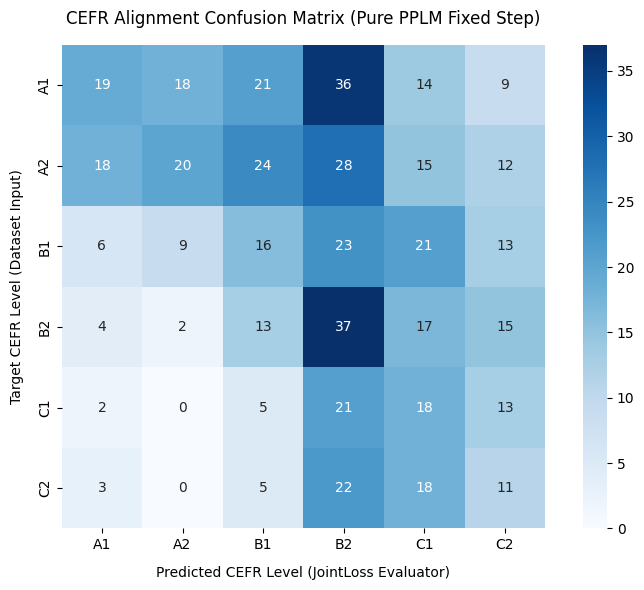

In [ ]:
# ==========================================
# 7. MACRO METRICS COMPILATION & EXPORT
# ==========================================
df_final = pd.read_csv(OUTPUT_CSV_PATH)
y_true_labels = df_final['target_cefr'].astype(str).str.strip().str.upper()
y_pred_labels = df_final['predicted_cefr'].astype(str).str.strip().str.upper()

# Calculate Macro Stats
y_true_num = y_true_labels.map(label_map)
y_pred_num = y_pred_labels.map(label_map)

total_samples = len(df_final)
strict_acc = df_final['strict_match'].mean() * 100
adj_acc = df_final['adjacent_match'].mean() * 100
mae = mean_absolute_error(y_true_num, y_pred_num)
avg_mdd = df_final['mdd'].mean()
avg_flesch = df_final['readability_flesch'].mean()
avg_drift = df_final['sentence_drift_max'].mean()

# Build TXT Report
report_text = "="*60 + "\n"
report_text += " 📊 FINAL COMPILED MACRO-STATISTICS (PURE PPLM)\n"
report_text += "="*60 + "\n"
report_text += f"Total Processed       : {total_samples}\n"
report_text += f"Strict Accuracy       : {strict_acc:.2f}%\n"
report_text += f"Adjacent Accuracy     : {adj_acc:.2f}%\n"
report_text += f"Mean Abs Error (MAE)  : {mae:.4f}\n"
report_text += f"Avg MDD Score         : {avg_mdd:.2f}\n"
report_text += f"Avg Reading Ease      : {avg_flesch:.2f}\n"
report_text += f"Avg Sentence Drift    : {avg_drift:.2f} levels\n"
report_text += "="*60 + "\n\n"

report_text += "📈 PERFORMANCE BREAKDOWN BY CEFR TARGET LEVEL:\n"
level_agg = df_final.groupby("target_cefr").agg(
    strict_accuracy=("strict_match", lambda x: np.mean(x) * 100),
    avg_mdd=("mdd", "mean"),
    avg_flesch=("readability_flesch", "mean"),
    avg_drift=("sentence_drift_max", "mean")
).round(2)
report_text += level_agg.to_string() + "\n\n"

report_text += "="*60 + "\n"
report_text += "📝 DETAILED CLASSIFICATION REPORT:\n"
cefr_labels = ["A1", "A2", "B1", "B2", "C1", "C2"]
report_text += classification_report(y_true_labels, y_pred_labels, labels=cefr_labels, zero_division=0)
report_text += "\n" + "="*60 + "\n"

# Save Text Report
with open(OUTPUT_TXT_PATH, "w") as f:
    f.write(report_text)
print(f"📄 Macro metrics report saved to: {OUTPUT_TXT_PATH}")
print(report_text)

# Generate and Save Confusion Matrix Plot
cm = confusion_matrix(y_true_labels, y_pred_labels, labels=cefr_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=cefr_labels, yticklabels=cefr_labels,
    cbar=True, square=True
)
plt.title("CEFR Alignment Confusion Matrix (Pure PPLM Fixed Step)", fontsize=12, pad=15)
plt.xlabel("Predicted CEFR Level (JointLoss Evaluator)", fontsize=10, labelpad=10)
plt.ylabel("Target CEFR Level (Dataset Input)", fontsize=10, labelpad=10)
plt.tight_layout()
plt.savefig(OUTPUT_IMG_PATH, dpi=300)
print(f"🎨 Confusion Matrix plot successfully saved to: {OUTPUT_IMG_PATH}")

## 3. Replication Runs and PPLM Temperature Sensitivity

This section executes the remaining replication runs required for the
three-run Base-LLM and PPLM comparison.

It includes:

- Base LLM runs 2 and 3 at `temperature = 0.6`;
- selected PPLM runs 2 and 3 at `temperature = 0.6`;
- additional PPLM sensitivity runs at temperatures `0.2` and `0.4`.

The selected PPLM hyperparameters remain fixed at `step_size = 0.5` and
`grad_steps = 20`.

In [ ]:
!pip install -q transformers torch datasets tqdm huggingface_hub accelerate scikit-learn textstat spacy
!python -m spacy download en_core_web_sm

import os
import gc
import torch
import spacy
import textstat
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSequenceClassification
from huggingface_hub import login, hf_hub_download
from google.colab import drive


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 76.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 126.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# ==========================================
# 0. CONFIGURATION & MASTER SETUP
# ==========================================
drive.mount('/content/drive')

INPUT_CSV_PATH = "/content/drive/MyDrive/Your_Path/in_domain_evaluation_prompt_matrix.csv"
hf_token = "HF_Token"
login(token=hf_token)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load NLP structural metrics tools once
nlp = spacy.load("en_core_web_sm")

Mounted at /content/drive
Using device: cuda


In [ ]:
# ==========================================
# 1. DEFINE THE QUEUE (6 AUTOMATED RUNS)
# ==========================================
queue_tasks = [
    {
        "id": 1,
        "name": "Base LLM - 2nd Replication Run",
        "type": "base",
        "temperature": 0.6,
        "batch_size": 256,
        "output_dir": "/content/drive/MyDrive/Your_Path/pplm_experiments/base_llm/2nd_run",
        "csv_file": "benchmark_results_basellm.csv",
        "txt_file": "overall_metrics_report.txt",
        "img_file": "confusion_matrix.png",
        "cm_title": "CEFR Level Confusion Matrix (Base LLM - Run 2)"
    },
    {
        "id": 2,
        "name": "Base LLM - 3rd Replication Run",
        "type": "base",
        "temperature": 0.6,
        "batch_size": 256,
        "output_dir": "/content/drive/MyDrive/Mohammd_Thesis/Results/BaseLLM/3rd_run",
        "csv_file": "benchmark_results_basellm.csv",
        "txt_file": "overall_metrics_report.txt",
        "img_file": "confusion_matrix.png",
        "cm_title": "CEFR Level Confusion Matrix (Base LLM - Run 3)"
    },
    {
        "id": 3,
        "name": "Pure PPLM Winner - 2nd Replication Run",
        "type": "pplm",
        "temperature": 0.6,
        "batch_size": 256 ,
        "output_dir": "/content/drive/MyDrive/Your_Path/pplm_experiments/pplm/2nd_run",
        "csv_file": "benchmark_results_pplm_pure.csv",
        "txt_file": "overall_metrics_report_pplm_pure.txt",
        "img_file": "confusion_matrix_pplm_pure.png",
        "cm_title": "CEFR Confusion Matrix (Pure PPLM - Run 2)"
    },
    {
        "id": 4,
        "name": "Pure PPLM Winner - 3rd Replication Run",
        "type": "pplm",
        "temperature": 0.6,
        "batch_size": 256 ,
        "output_dir": "/content/drive/MyDrive/Your_Path/pplm_experiments/pplm/3rd_run",
        "csv_file": "benchmark_results_pplm_pure.csv",
        "txt_file": "overall_metrics_report_pplm_pure.txt",
        "img_file": "confusion_matrix_pplm_pure.png",
        "cm_title": "CEFR Confusion Matrix (Pure PPLM - Run 3)"
    },
    {
        "id": 5,
        "name": "Pure PPLM Winner - Sensitivity Temp 0.2",
        "type": "pplm",
        "temperature": 0.2,
        "batch_size": 256,
        "output_dir": "/content/drive/MyDrive/Your_Path/pplm_experiments/pplm/temp_0.2",
        "csv_file": "benchmark_results_pplm_pure.csv",
        "txt_file": "overall_metrics_report_pplm_pure.txt",
        "img_file": "confusion_matrix_pplm_pure.png",
        "cm_title": "CEFR Confusion Matrix (Pure PPLM - Temp 0.2)"
    },
    {
        "id": 6,
        "name": "Pure PPLM Winner - Sensitivity Temp 0.4",
        "type": "pplm",
        "temperature": 0.4,
        "batch_size": 256,
        "output_dir": "/content/drive/MyDrive/Your_Path/pplm_experiments/pplm/temp_0.4",
        "csv_file": "benchmark_results_pplm_pure.csv",
        "txt_file": "overall_metrics_report_pplm_pure.txt",
        "img_file": "confusion_matrix_pplm_pure.png",
        "cm_title": "CEFR Confusion Matrix (Pure PPLM - Temp 0.4)"
    }
]


In [ ]:
# ==========================================
# 2. LOAD ALL WEIGHT ARCHITECTURES ONCE
# ==========================================
# =========================================================
# LOAD THE PPLM CEFR LATENT CLASSIFIER
# =========================================================

print("Loading PPLM CEFR single-layer latent classifier...")

class CEFRLatentClassifier(nn.Module):
    def __init__(self, input_dim=4096, num_classes=6):
        super().__init__()
        self.network = nn.Sequential(
            nn.Dropout(p=0.35),
            nn.Linear(input_dim, num_classes)
        )

    def forward(self, x):
        return self.network(x)


target_repo_id = (
    "MohammadKhosravi/"
    "llama3.1-8b-cefr-steering-1layer-head-ordinal-universal"
)

steering_head = CEFRLatentClassifier().to(device)

weights_path = hf_hub_download(
    repo_id=target_repo_id,
    filename="cefr_steering_head_universal_ordinal.pt"
)

steering_head.load_state_dict(
    torch.load(weights_path, map_location=device)
)

steering_head.eval()

criterion = nn.CrossEntropyLoss(reduction="none")

In [ ]:
# ==========================================
# 3. RUNTIME LINGUISTIC METHODS
# ==========================================
def calculate_mdd(text):
    doc = nlp(text)
    total_dist, tokens = 0, 0
    for token in doc:
        if token.dep_ != "punct":
            total_dist += abs(token.i - token.head.i)
            tokens += 1
    return total_dist / tokens if tokens > 0 else 0.0

def calculate_sentence_drift(text, judge_model, judge_tokenizer):
    doc = nlp(text)
    sentences = [sent.text.strip() for sent in doc.sents if len(sent.text.strip()) > 10]
    if len(sentences) <= 1: return 0
    inputs = judge_tokenizer(sentences, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
    with torch.no_grad():
        preds = torch.argmax(judge_model(**inputs).logits, dim=-1).cpu().numpy()
    return int(np.max(preds) - np.min(preds))


In [ ]:
# ==========================================
# 4. MULTI-RUN QUEUE LOOP EXECUTION
# ==========================================
df_prompts = pd.read_csv(INPUT_CSV_PATH)
repetition_penalty = 1.15
max_new_tokens = 200
top_k = 50

print(f"\n===========================================================")
print(f"🎬 STARTING AUTOMATED QUEUE ENGINE: 6 TASKS IN PIPELINE")
print(f"===========================================================")

for task in queue_tasks:
    print(f"\n⚡ Task [{task['id']}/6]: Processing '{task['name']}'...")

    # Instantiate targets and clean output folders
    os.makedirs(task['output_dir'], exist_ok=True)
    out_csv = os.path.join(task['output_dir'], task['csv_file'])
    out_txt = os.path.join(task['output_dir'], task['txt_file'])
    out_img = os.path.join(task['output_dir'], task['img_file'])

    # Resumption condition block
    if os.path.exists(out_txt) and os.path.exists(out_csv):
        print(f"⏭️ Skipping Task {task['id']} - complete artifacts located.")
        continue

    results = []
    b_size = task['batch_size']
    temp = task['temperature']

    # --------------------------------------------------
    # ENGINE BLOCK A: BASE LLM INFERENCE GENERATION
    # --------------------------------------------------
    if task['type'] == "base":
        print(f"-> Mode: Unsteered Base Generation (Batch Size: {b_size}, Temp: {temp})")
        for b_start in range(0, len(df_prompts), b_size):
            batch_df = df_prompts.iloc[b_start : b_start + b_size]
            current_batch_size = len(batch_df)

            batch_prompts, batch_targets, batch_topic_ids, batch_titles = [], [], [], []
            for _, row in batch_df.iterrows():
                t_cefr = str(row['cefr']).strip().upper()
                batch_targets.append(t_cefr)
                batch_topic_ids.append(row['topic_id'])
                batch_titles.append(row['topic_title'])

                sys_instr = (
                    f"You are an expert English language teacher demonstrating CEFR proficiency levels. "
                    f"Your task is to write a flawless, grammatically correct text responding to this prompt: '{row['topic_title']}'. "
                    f"The output must serve as a perfect textbook example of strictly {t_cefr} level English. "
                    f"If the requested target level is A1/A2, use very simple vocabulary, short sentences, and primitive structures. "
                    f"If the requested target level is C1/C2, utilize highly advanced vocabulary, idioms, and complex sentence patterns. "
                    f"Write only the direct response. Do not write any meta-commentary, greetings, or conversational pleasantries."
                )
                messages = [{"role": "system", "content": sys_instr}, {"role": "user", "content": row['topic_title']}]
                batch_prompts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))

            inputs = tokenizer(batch_prompts, padding=True, return_tensors="pt").to(device)
            with torch.no_grad():
                base_outputs = model.generate(
                    inputs.input_ids, attention_mask=inputs.attention_mask,
                    max_new_tokens=max_new_tokens, temperature=temp, do_sample=True,
                    top_k=top_k, repetition_penalty=repetition_penalty,
                    pad_token_id=tokenizer.pad_token_id, eos_token_id=eos_ids
                )

            batch_gen_texts = []
            for b_idx in range(current_batch_size):
                gen_tokens = base_outputs[b_idx][inputs.input_ids.shape[1]:]
                batch_gen_texts.append(tokenizer.decode(gen_tokens, skip_special_tokens=True).strip())

            # Evaluation Processing Block
            eval_inputs = judge_tokenizer(batch_gen_texts, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
            with torch.no_grad():
                eval_preds = torch.argmax(judge_model(**eval_inputs).logits, dim=-1).cpu().numpy()

            for b_idx in range(current_batch_size):
                target_cefr = batch_targets[b_idx]
                predicted_cefr = inv_label_map[eval_preds[b_idx]]
                gen_text = batch_gen_texts[b_idx]

                results.append({
                    "topic_id": batch_topic_ids[b_idx], "topic_title": batch_titles[b_idx],
                    "target_cefr": target_cefr, "predicted_cefr": predicted_cefr,
                    "strict_match": int(predicted_cefr == target_cefr),
                    "adjacent_match": int(abs(label_map[predicted_cefr] - label_map[target_cefr]) <= 1),
                    "mdd": round(calculate_mdd(gen_text), 2),
                    "readability_flesch": round(textstat.flesch_reading_ease(gen_text), 2),
                    "sentence_drift_max": calculate_sentence_drift(gen_text, judge_model, judge_tokenizer),
                    "generated_text": gen_text
                })
            del inputs, base_outputs, eval_inputs
            torch.cuda.empty_cache()

    # --------------------------------------------------
    # ENGINE BLOCK B: PURE PPLM STEERED INFERENCE
    # --------------------------------------------------
    elif task['type'] == "pplm":
        step_sz = 0.5
        g_steps = 20
        print(f"-> Mode: Pure PPLM Steering (Batch Size: {b_size}, Temp: {temp}, Step: {step_sz}, Grads: {g_steps})")

        for b_start in range(0, len(df_prompts), b_size):
            batch_df = df_prompts.iloc[b_start : b_start + b_size]
            current_batch_size = len(batch_df)

            batch_prompts, batch_targets, batch_target_ids, batch_topic_ids, batch_titles = [], [], [], [], []
            for _, row in batch_df.iterrows():
                t_cefr = str(row['cefr']).strip().upper()
                batch_targets.append(t_cefr)
                batch_target_ids.append(label_map[t_cefr])
                batch_topic_ids.append(row['topic_id'])
                batch_titles.append(row['topic_title'])

                sys_instr = (
                    f"You are an expert English language teacher demonstrating CEFR proficiency levels. "
                    f"Your task is to write a flawless, grammatically correct text responding to this prompt: '{row['topic_title']}'. "
                    f"The output must serve as a perfect textbook example of strictly {t_cefr} level English. "
                    f"If the requested target level is A1/A2, use very simple vocabulary, short sentences, and primitive structures. "
                    f"If the requested target level is C1/C2, utilize highly advanced vocabulary, idioms, and complex sentence patterns. "
                    f"Write only the direct response. Do not write any meta-commentary, greetings, or conversational pleasantries."
                )
                messages = [{"role": "system", "content": sys_instr}, {"role": "user", "content": row['topic_title']}]
                batch_prompts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))

            inputs = tokenizer(batch_prompts, padding=True, return_tensors="pt").to(device)
            input_ids, attention_mask = inputs.input_ids, inputs.attention_mask

            finished = torch.zeros(current_batch_size, dtype=torch.bool, device=device)
            generated_tokens = [[] for _ in range(current_batch_size)]
            batch_target_ids_tensor = torch.tensor(batch_target_ids, device=device)

            past_key_values = None
            current_attention_mask = attention_mask

            # Autoregressive PPLM Generation Nested Execution Loop
            for step_idx in range(max_new_tokens):
                model_input = input_ids if step_idx == 0 else next_token_ids.unsqueeze(-1)
                if step_idx > 0:
                    current_attention_mask = torch.cat([current_attention_mask, torch.ones(current_batch_size, 1, dtype=torch.long, device=device)], dim=-1)

                with torch.no_grad():
                    outputs = model(input_ids=model_input, attention_mask=current_attention_mask, past_key_values=past_key_values, use_cache=True, output_hidden_states=True)
                past_key_values = outputs.past_key_values

                hidden_state_prenorm = outputs.hidden_states[-2][:, -1, :].detach().clone().to(torch.float32)
                hidden_state_prenorm.requires_grad_(True)

                for g_step in range(g_steps):
                    class_logits = steering_head(hidden_state_prenorm)
                    loss_vector = criterion(class_logits, batch_target_ids_tensor)
                    active_mask = (~finished).float()
                    loss = (loss_vector * active_mask).sum()
                    if loss.item() == 0: break
                    loss.backward()

                    with torch.no_grad():
                        raw_grad = hidden_state_prenorm.grad.data
                        grad_norms = torch.norm(raw_grad, p=2, dim=-1, keepdim=True) + 1e-9
                        normalized_grad = raw_grad / grad_norms
                        hidden_state_prenorm.data = hidden_state_prenorm.data - (step_sz * normalized_grad * active_mask.unsqueeze(-1))
                        hidden_state_prenorm.grad.zero_()

                with torch.no_grad():
                    steered_normed = model.model.norm(hidden_state_prenorm.to(torch.bfloat16))
                    lm_logits = model.lm_head(steered_normed)

                    for b_idx in range(current_batch_size):
                        for tok_id in set(generated_tokens[b_idx] + input_ids[b_idx].tolist()):
                            if lm_logits[b_idx, tok_id] > 0: lm_logits[b_idx, tok_id] /= repetition_penalty
                            else: lm_logits[b_idx, tok_id] *= repetition_penalty

                    lm_logits = lm_logits / temp
                    values, indices = torch.topk(lm_logits, top_k, dim=-1)
                    filtered_logits = torch.full_like(lm_logits, float('-inf')).scatter_(1, indices, values)
                    probs_lm = F.softmax(filtered_logits, dim=-1)
                    next_token_ids = torch.multinomial(probs_lm, num_samples=1).squeeze(-1)

                    for b_idx in range(current_batch_size):
                        if not finished[b_idx]:
                            generated_tokens[b_idx].append(next_token_ids[b_idx].item())
                            if next_token_ids[b_idx].item() in eos_ids:
                                finished[b_idx] = True
                if finished.all(): break

            batch_gen_texts = [tokenizer.decode(generated_tokens[b_idx], skip_special_tokens=True).strip() for b_idx in range(current_batch_size)]
            eval_inputs = judge_tokenizer(batch_gen_texts, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
            with torch.no_grad():
                eval_preds = torch.argmax(judge_model(**eval_inputs).logits, dim=-1).cpu().numpy()

            for b_idx in range(current_batch_size):
                target_cefr = batch_targets[b_idx]
                predicted_cefr = inv_label_map[eval_preds[b_idx]]
                gen_text = batch_gen_texts[b_idx]

                results.append({
                    "topic_id": batch_topic_ids[b_idx], "topic_title": batch_titles[b_idx],
                    "target_cefr": target_cefr, "predicted_cefr": predicted_cefr,
                    "strict_match": int(predicted_cefr == target_cefr),
                    "adjacent_match": int(abs(label_map[predicted_cefr] - label_map[target_cefr]) <= 1),
                    "mdd": round(calculate_mdd(gen_text), 2),
                    "readability_flesch": round(textstat.flesch_reading_ease(gen_text), 2),
                    "sentence_drift_max": calculate_sentence_drift(gen_text, judge_model, judge_tokenizer),
                    "generated_text": gen_text
                })
            del inputs, eval_inputs
            torch.cuda.empty_cache()

    # --------------------------------------------------
    # POST-RUN COMPILATION AND REPOSITORY WRITING
    # --------------------------------------------------
    df_final = pd.DataFrame(results)
    df_final.to_csv(out_csv, index=False)

    y_true_labels = df_final['target_cefr'].astype(str).str.strip().str.upper()
    y_pred_labels = df_final['predicted_cefr'].astype(str).str.strip().str.upper()
    y_true_num = y_true_labels.map(label_map)
    y_pred_num = y_pred_labels.map(label_map)

    strict_acc = df_final['strict_match'].mean() * 100
    adj_acc = df_final['adjacent_match'].mean() * 100
    mae = mean_absolute_error(y_true_num, y_pred_num)
    avg_mdd = df_final['mdd'].mean()
    avg_flesch = df_final['readability_flesch'].mean()
    avg_drift = df_final['sentence_drift_max'].mean()

    report_text = "="*60 + "\n"
    report_text += f" 📊 METRICS EXPORT REPORT: {task['name']}\n"
    report_text += "="*60 + "\n"
    report_text += f"Total Processed       : {len(df_final)}\n"
    report_text += f"Strict Accuracy       : {strict_acc:.2f}%\n"
    report_text += f"Adjacent Accuracy     : {adj_acc:.2f}%\n"
    report_text += f"Mean Abs Error (MAE)  : {mae:.4f}\n"
    report_text += f"Avg MDD Score         : {avg_mdd:.2f}\n"
    report_text += f"Avg Reading Ease      : {avg_flesch:.2f}\n"
    report_text += f"Avg Sentence Drift    : {avg_drift:.2f} levels\n"
    report_text += "="*60 + "\n\n"

    report_text += "📈 PERFORMANCE BREAKDOWN BY CEFR TARGET LEVEL:\n"
    level_agg = df_final.groupby("target_cefr").agg(
        strict_accuracy=("strict_match", lambda x: np.mean(x) * 100),
        avg_mdd=("mdd", "mean"),
        avg_flesch=("readability_flesch", "mean"),
        avg_drift=("sentence_drift_max", "mean")
    ).round(2)
    report_text += level_agg.to_string() + "\n\n"

    report_text += "="*60 + "\n"
    report_text += "📝 DETAILED CLASSIFICATION REPORT:\n"
    cefr_labels = ["A1", "A2", "B1", "B2", "C1", "C2"]
    report_text += classification_report(y_true_labels, y_pred_labels, labels=cefr_labels, zero_division=0)
    report_text += "\n" + "="*60 + "\n"

    with open(out_txt, "w") as f: f.write(report_text)

    # Generate Heatmap Matrix
    cm = confusion_matrix(y_true_labels, y_pred_labels, labels=cefr_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cefr_labels, yticklabels=cefr_labels, cbar=True, square=True)
    plt.title(task['cm_title'], fontsize=11, pad=12)
    plt.xlabel("Predicted CEFR Level")
    plt.ylabel("Target CEFR Level")
    plt.tight_layout()
    plt.savefig(out_img, dpi=300)
    plt.close()

    print(f"🏁 Task [{task['id']}/6] Complete. Results saved inside folder: {task['output_dir']}")

    gc.collect()
    torch.cuda.empty_cache()

print("\n🎉 All tasks in the Queue and Sleep pipeline have finished execution successfully!")


🎬 STARTING AUTOMATED QUEUE ENGINE: 6 TASKS IN PIPELINE

⚡ Task [1/6]: Processing 'Base LLM - 2nd Replication Run'...
-> Mode: Unsteered Base Generation (Batch Size: 256, Temp: 0.6)


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


🏁 Task [1/6] Complete. Results saved inside folder: /content/drive/MyDrive/Mohammd_Thesis/Results/BaseLLM/2nd_run

⚡ Task [2/6]: Processing 'Base LLM - 3rd Replication Run'...
-> Mode: Unsteered Base Generation (Batch Size: 256, Temp: 0.6)
🏁 Task [2/6] Complete. Results saved inside folder: /content/drive/MyDrive/Mohammd_Thesis/Results/BaseLLM/3rd_run

⚡ Task [3/6]: Processing 'Pure PPLM Winner - 2nd Replication Run'...
-> Mode: Pure PPLM Steering (Batch Size: 256, Temp: 0.6, Step: 0.5, Grads: 20)
🏁 Task [3/6] Complete. Results saved inside folder: /content/drive/MyDrive/Mohammd_Thesis/Results/PPLM_Pure/Winner/2nd_run

⚡ Task [4/6]: Processing 'Pure PPLM Winner - 3rd Replication Run'...
-> Mode: Pure PPLM Steering (Batch Size: 256, Temp: 0.6, Step: 0.5, Grads: 20)
🏁 Task [4/6] Complete. Results saved inside folder: /content/drive/MyDrive/Mohammd_Thesis/Results/PPLM_Pure/Winner/3rd_run

⚡ Task [5/6]: Processing 'Pure PPLM Winner - Sensitivity Temp 0.2'...
-> Mode: Pure PPLM Steering (Ba

## 4. Base LLM Temperature-Sensitivity Runs

This section evaluates the Base LLM at temperatures `0.4` and `0.2` for
comparison with the corresponding PPLM sensitivity experiments.

In [ ]:
!pip install -q transformers torch datasets tqdm huggingface_hub accelerate scikit-learn textstat spacy
!python -m spacy download en_core_web_sm

import os
import gc
import torch
import spacy
import textstat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSequenceClassification
from huggingface_hub import login
from google.colab import drive

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 112.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 150.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# ==========================================
# 0. CONFIGURATION & MASTER SETUP
# ==========================================
drive.mount('/content/drive')

INPUT_CSV_PATH = "/content/drive/MyDrive/Your_Path/in_domain_evaluation_prompt_matrix.csv"
hf_token = "HF_Token"
login(token=hf_token)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load NLP structural metrics tools once
nlp = spacy.load("en_core_web_sm")

Mounted at /content/drive
Using device: cuda


In [ ]:
# ==========================================
# 1. DEFINE THE QUEUE (2 AUTOMATED RUNS)
# ==========================================
queue_tasks = [
    {
        "id": 1,
        "name": "Base LLM - 2nd Replication Run",
        "type": "base",
        "temperature": 0.4,
        "batch_size": 256,
        "output_dir": "/content/drive/MyDrive/Your_Path/pplm_experiments/base_llm/temp_0.4",
        "csv_file": "benchmark_results_basellm.csv",
        "txt_file": "overall_metrics_report.txt",
        "img_file": "confusion_matrix.png",
        "cm_title": "CEFR Level Confusion Matrix (Base LLM - temp_0.4)"
    },
    {
        "id": 2,
        "name": "Base LLM - 3rd Replication Run",
        "type": "base",
        "temperature": 0.2,
        "batch_size": 256,
        "output_dir": "/content/drive/MyDrive/Your_Path/pplm_experiments/base_llm/temp_0.2",
        "csv_file": "benchmark_results_basellm.csv",
        "txt_file": "overall_metrics_report.txt",
        "img_file": "confusion_matrix.png",
        "cm_title": "CEFR Level Confusion Matrix (Base LLM - temp_0.2)"
    }
]


In [ ]:
# ==========================================
# 2. LOAD ARCHITECTURES ONCE
# ==========================================
print("\nLoading Base Llama-3.1-8B-Instruct...")
model_id = "meta-llama/Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

eot_id = tokenizer.convert_tokens_to_ids("<|eot_id|>\n") if tokenizer.convert_tokens_to_ids("<|eot_id|>\n") is not None else tokenizer.convert_tokens_to_ids("<|eot_id|>. ")
if eot_id is None:
    eot_id = tokenizer.convert_tokens_to_ids("<|eot_id|>")
eos_ids = [tokenizer.eos_token_id]
if eot_id is not None:
    eos_ids.append(eot_id)

model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.bfloat16, device_map="auto")
model.eval()

print("Loading Custom JointLoss RoBERTa Evaluator...")
JUDGE_MODEL_ID = "MohammadKhosravi/roberta-large-cefr-classifier-JointLoss"
judge_tokenizer = AutoTokenizer.from_pretrained(JUDGE_MODEL_ID)
judge_model = AutoModelForSequenceClassification.from_pretrained(JUDGE_MODEL_ID).to(device)
judge_model.eval()

label_map = {"A1": 0, "A2": 1, "B1": 2, "B2": 3, "C1": 4, "C2": 5}
inv_label_map = {0: "A1", 1: "A2", 2: "B1", 3: "B2", 4: "C1", 5: "C2"}


Loading Base Llama-3.1-8B-Instruct...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/388 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.56M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.42GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

In [ ]:
# ==========================================
# 3. RUNTIME LINGUISTIC METHODS
# ==========================================
def calculate_mdd(text):
    doc = nlp(text)
    total_dist, tokens = 0, 0
    for token in doc:
        if token.dep_ != "punct":
            total_dist += abs(token.i - token.head.i)
            tokens += 1
    return total_dist / tokens if tokens > 0 else 0.0

def calculate_sentence_drift(text, judge_model, judge_tokenizer):
    doc = nlp(text)
    sentences = [sent.text.strip() for sent in doc.sents if len(sent.text.strip()) > 10]
    if len(sentences) <= 1: return 0
    inputs = judge_tokenizer(sentences, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
    with torch.no_grad():
        preds = torch.argmax(judge_model(**inputs).logits, dim=-1).cpu().numpy()
    return int(np.max(preds) - np.min(preds))

In [ ]:
# ==========================================
# 4. MULTI-RUN QUEUE LOOP EXECUTION
# ==========================================
df_prompts = pd.read_csv(INPUT_CSV_PATH)
repetition_penalty = 1.15
max_new_tokens = 200
top_k = 50

print(f"\n===========================================================")
print(f"🎬 STARTING AUTOMATED QUEUE ENGINE: 2 TASKS IN PIPELINE")
print(f"===========================================================")

for task in queue_tasks:
    print(f"\n⚡ Task [{task['id']}/2]: Processing '{task['name']}'...")

    # Instantiate targets and clean output folders
    os.makedirs(task['output_dir'], exist_ok=True)
    out_csv = os.path.join(task['output_dir'], task['csv_file'])
    out_txt = os.path.join(task['output_dir'], task['txt_file'])
    out_img = os.path.join(task['output_dir'], task['img_file'])

    # Resumption condition block
    if os.path.exists(out_txt) and os.path.exists(out_csv):
        print(f"⏭️ Skipping Task {task['id']} - complete artifacts located.")
        continue

    results = []
    b_size = task['batch_size']
    temp = task['temperature']

    # --------------------------------------------------
    # ENGINE BLOCK A: BASE LLM INFERENCE GENERATION
    # --------------------------------------------------
    if task['type'] == "base":
        print(f"-> Mode: Unsteered Base Generation (Batch Size: {b_size}, Temp: {temp})")
        for b_start in range(0, len(df_prompts), b_size):
            batch_df = df_prompts.iloc[b_start : b_start + b_size]
            current_batch_size = len(batch_df)

            batch_prompts, batch_targets, batch_topic_ids, batch_titles = [], [], [], []
            for _, row in batch_df.iterrows():
                t_cefr = str(row['cefr']).strip().upper()
                batch_targets.append(t_cefr)
                batch_topic_ids.append(row['topic_id'])
                batch_titles.append(row['topic_title'])

                sys_instr = (
                    f"You are an expert English language teacher demonstrating CEFR proficiency levels. "
                    f"Your task is to write a flawless, grammatically correct text responding to this prompt: '{row['topic_title']}'. "
                    f"The output must serve as a perfect textbook example of strictly {t_cefr} level English. "
                    f"If the requested target level is A1/A2, use very simple vocabulary, short sentences, and primitive structures. "
                    f"If the requested target level is C1/C2, utilize highly advanced vocabulary, idioms, and complex sentence patterns. "
                    f"Write only the direct response. Do not write any meta-commentary, greetings, or conversational pleasantries."
                )
                messages = [{"role": "system", "content": sys_instr}, {"role": "user", "content": row['topic_title']}]
                batch_prompts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))

            inputs = tokenizer(batch_prompts, padding=True, return_tensors="pt").to(device)
            with torch.no_grad():
                base_outputs = model.generate(
                    inputs.input_ids, attention_mask=inputs.attention_mask,
                    max_new_tokens=max_new_tokens, temperature=temp, do_sample=True,
                    top_k=top_k, repetition_penalty=repetition_penalty,
                    pad_token_id=tokenizer.pad_token_id, eos_token_id=eos_ids
                )

            batch_gen_texts = []
            for b_idx in range(current_batch_size):
                gen_tokens = base_outputs[b_idx][inputs.input_ids.shape[1]:]
                batch_gen_texts.append(tokenizer.decode(gen_tokens, skip_special_tokens=True).strip())

            # Evaluation Processing Block
            eval_inputs = judge_tokenizer(batch_gen_texts, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
            with torch.no_grad():
                eval_preds = torch.argmax(judge_model(**eval_inputs).logits, dim=-1).cpu().numpy()

            for b_idx in range(current_batch_size):
                target_cefr = batch_targets[b_idx]
                predicted_cefr = inv_label_map[eval_preds[b_idx]]
                gen_text = batch_gen_texts[b_idx]

                results.append({
                    "topic_id": batch_topic_ids[b_idx], "topic_title": batch_titles[b_idx],
                    "target_cefr": target_cefr, "predicted_cefr": predicted_cefr,
                    "strict_match": int(predicted_cefr == target_cefr),
                    "adjacent_match": int(abs(label_map[predicted_cefr] - label_map[target_cefr]) <= 1),
                    "mdd": round(calculate_mdd(gen_text), 2),
                    "readability_flesch": round(textstat.flesch_reading_ease(gen_text), 2),
                    "sentence_drift_max": calculate_sentence_drift(gen_text, judge_model, judge_tokenizer),
                    "generated_text": gen_text
                })
            del inputs, base_outputs, eval_inputs
            torch.cuda.empty_cache()

    # --------------------------------------------------
    # POST-RUN COMPILATION AND REPOSITORY WRITING
    # --------------------------------------------------
    df_final = pd.DataFrame(results)
    df_final.to_csv(out_csv, index=False)

    y_true_labels = df_final['target_cefr'].astype(str).str.strip().str.upper()
    y_pred_labels = df_final['predicted_cefr'].astype(str).str.strip().str.upper()
    y_true_num = y_true_labels.map(label_map)
    y_pred_num = y_pred_labels.map(label_map)

    strict_acc = df_final['strict_match'].mean() * 100
    adj_acc = df_final['adjacent_match'].mean() * 100
    mae = mean_absolute_error(y_true_num, y_pred_num)
    avg_mdd = df_final['mdd'].mean()
    avg_flesch = df_final['readability_flesch'].mean()
    avg_drift = df_final['sentence_drift_max'].mean()

    report_text = "="*60 + "\n"
    report_text += f" 📊 METRICS EXPORT REPORT: {task['name']}\n"
    report_text += "="*60 + "\n"
    report_text += f"Total Processed       : {len(df_final)}\n"
    report_text += f"Strict Accuracy       : {strict_acc:.2f}%\n"
    report_text += f"Adjacent Accuracy     : {adj_acc:.2f}%\n"
    report_text += f"Mean Abs Error (MAE)  : {mae:.4f}\n"
    report_text += f"Avg MDD Score         : {avg_mdd:.2f}\n"
    report_text += f"Avg Reading Ease      : {avg_flesch:.2f}\n"
    report_text += f"Avg Sentence Drift    : {avg_drift:.2f} levels\n"
    report_text += "="*60 + "\n\n"

    report_text += "📈 PERFORMANCE BREAKDOWN BY CEFR TARGET LEVEL:\n"
    level_agg = df_final.groupby("target_cefr").agg(
        strict_accuracy=("strict_match", lambda x: np.mean(x) * 100),
        avg_mdd=("mdd", "mean"),
        avg_flesch=("readability_flesch", "mean"),
        avg_drift=("sentence_drift_max", "mean")
    ).round(2)
    report_text += level_agg.to_string() + "\n\n"

    report_text += "="*60 + "\n"
    report_text += "📝 DETAILED CLASSIFICATION REPORT:\n"
    cefr_labels = ["A1", "A2", "B1", "B2", "C1", "C2"]
    report_text += classification_report(y_true_labels, y_pred_labels, labels=cefr_labels, zero_division=0)
    report_text += "\n" + "="*60 + "\n"

    with open(out_txt, "w") as f: f.write(report_text)

    # Generate Heatmap Matrix
    cm = confusion_matrix(y_true_labels, y_pred_labels, labels=cefr_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cefr_labels, yticklabels=cefr_labels, cbar=True, square=True)
    plt.title(task['cm_title'], fontsize=11, pad=12)
    plt.xlabel("Predicted CEFR Level")
    plt.ylabel("Target CEFR Level")
    plt.tight_layout()
    plt.savefig(out_img, dpi=300)
    plt.close()

    print(f"🏁 Task [{task['id']}/2] Complete. Results saved inside folder: {task['output_dir']}")

    gc.collect()
    torch.cuda.empty_cache()

print("\n🎉 All tasks in the Queue and Sleep pipeline have finished execution successfully!")


🎬 STARTING AUTOMATED QUEUE ENGINE: 2 TASKS IN PIPELINE

⚡ Task [1/2]: Processing 'Base LLM - 2nd Replication Run'...
-> Mode: Unsteered Base Generation (Batch Size: 256, Temp: 0.4)


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


🏁 Task [1/2] Complete. Results saved inside folder: /content/drive/MyDrive/Mohammd_Thesis/Results/BaseLLM/temp_0.4

⚡ Task [2/2]: Processing 'Base LLM - 3rd Replication Run'...
-> Mode: Unsteered Base Generation (Batch Size: 256, Temp: 0.2)
🏁 Task [2/2] Complete. Results saved inside folder: /content/drive/MyDrive/Mohammd_Thesis/Results/BaseLLM/temp_0.2

🎉 All tasks in the Queue and Sleep pipeline have finished execution successfully!
